Libraries imported successfully!
Running Device:
cpu

Configuration
----------------------------
Image Size       : 32
Batch Size       : 8
Training Images  : 400
Validation Images: 100

Image Transformation Created


100%|████████████████████████████████████████████████████████████████████████████████| 170M/170M [27:36<00:00, 103kB/s]
C:\Users\SaiVamshiGudem\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")



Dataset created successfully!
Training samples: 400
Validation samples: 100

Classes:
0 → airplane
1 → automobile
2 → bird
3 → cat
4 → deer
5 → dog
6 → frog
7 → horse
8 → ship
9 → truck

DataLoaders created successfully!

Batch Information
Image Shape: torch.Size([8, 3, 32, 32])
Label Shape: torch.Size([8])


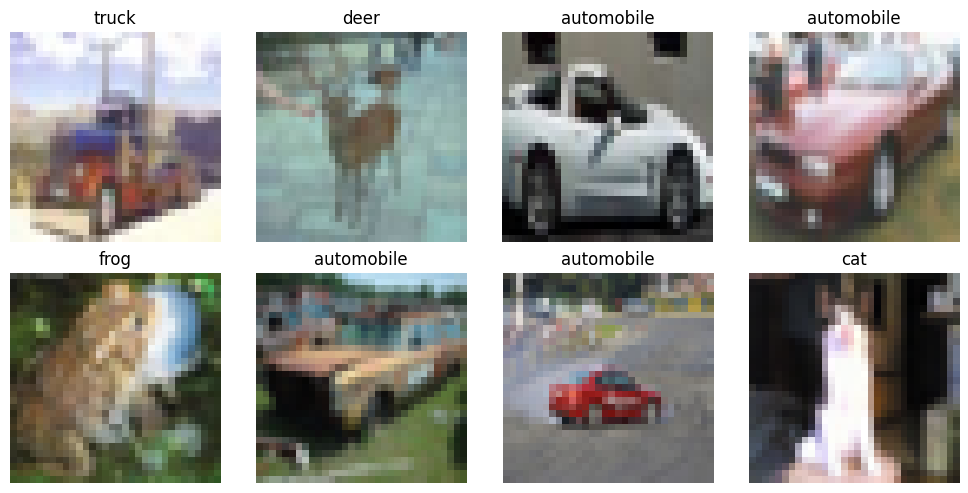


Image-Text Dataset:


,question,answer
0,What object is shown in the image?,truck
1,What object is shown in the image?,deer
2,What object is shown in the image?,automobile
3,What object is shown in the image?,automobile
4,What object is shown in the image?,frog



Multimodal Samples:


,question,answer,description
0,What object is shown in the image?,truck,This image contains a truck.
1,What object is shown in the image?,deer,This image contains a deer.
2,What object is shown in the image?,automobile,This image contains a automobile.
3,What object is shown in the image?,automobile,This image contains a automobile.
4,What object is shown in the image?,frog,This image contains a frog.
5,What object is shown in the image?,automobile,This image contains a automobile.
6,What object is shown in the image?,automobile,This image contains a automobile.
7,What object is shown in the image?,cat,This image contains a cat.



DATASET STATISTICS
Total Images Used: 500
Training Images: 400
Validation Images: 100
Image Resolution: 32 × 32
Number of Classes: 10

Class Distribution in Sample Batch:
truck : 1
deer : 1
automobile : 4
frog : 1
cat : 1

PART 1 COMPLETED

✔ Built-in CIFAR-10 dataset loaded

✔ Small subset selected

✔ Images resized

✔ Images normalized

✔ Train / validation datasets created

✔ DataLoaders created

✔ Image samples visualized

✔ Image + question pairs created

✔ Multimodal data prepared

READY FOR PART 2



In [1]:
# ============================================================
# MULTIMODAL AI / VISION-LANGUAGE MODEL
# PROJECT : IMAGE + TEXT UNDERSTANDING
# PART 1 : DATASET + IMAGE PREPROCESSING
# ============================================================


# ============================================================
# SECTION 1 : IMPORT LIBRARIES
# ============================================================

import torch
import torchvision
import torchvision.transforms as transforms

import pandas as pd
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, Subset


print("Libraries imported successfully!")


# ============================================================
# SECTION 2 : CHECK DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Running Device:")
print(device)


# ============================================================
# SECTION 3 : DEFINE HARDWARE-FRIENDLY SETTINGS
# ============================================================

IMAGE_SIZE = 32

BATCH_SIZE = 8

TRAIN_SIZE = 400

VALIDATION_SIZE = 100


print("\nConfiguration")
print("----------------------------")
print("Image Size       :", IMAGE_SIZE)
print("Batch Size       :", BATCH_SIZE)
print("Training Images  :", TRAIN_SIZE)
print("Validation Images:", VALIDATION_SIZE)


# ============================================================
# SECTION 4 : DEFINE IMAGE TRANSFORMATION
# ============================================================

transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )

])


print("\nImage Transformation Created")


# ============================================================
# SECTION 5 : LOAD CIFAR-10 DATASET
# ============================================================

# CIFAR-10 is a predefined computer vision dataset.
#
# Only a small subset will be used.
#
# This keeps CPU and memory usage low.


train_full = torchvision.datasets.CIFAR10(

    root="./data",

    train=True,

    download=True,

    transform=transform

)


# ============================================================
# SECTION 6 : SELECT SMALL SUBSET
# ============================================================

train_indices = list(
    range(TRAIN_SIZE)
)

validation_indices = list(
    range(
        TRAIN_SIZE,
        TRAIN_SIZE + VALIDATION_SIZE
    )
)


train_dataset = Subset(
    train_full,
    train_indices
)


validation_dataset = Subset(
    train_full,
    validation_indices
)


print("\nDataset created successfully!")

print(
    "Training samples:",
    len(train_dataset)
)

print(
    "Validation samples:",
    len(validation_dataset)
)


# ============================================================
# SECTION 7 : CIFAR-10 CLASS NAMES
# ============================================================

class_names = [

    "airplane",

    "automobile",

    "bird",

    "cat",

    "deer",

    "dog",

    "frog",

    "horse",

    "ship",

    "truck"

]


print("\nClasses:")

for index, class_name in enumerate(class_names):

    print(
        index,
        "→",
        class_name
    )


# ============================================================
# SECTION 8 : CREATE DATA LOADERS
# ============================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=0

)


validation_loader = DataLoader(

    validation_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0

)


print("\nDataLoaders created successfully!")


# ============================================================
# SECTION 9 : LOAD ONE BATCH
# ============================================================

images, labels = next(
    iter(train_loader)
)


print("\nBatch Information")

print(
    "Image Shape:",
    images.shape
)

print(
    "Label Shape:",
    labels.shape
)


# ============================================================
# SECTION 10 : DISPLAY SAMPLE IMAGES
# ============================================================

# Convert normalized image back to display range.

display_images = (
    images * 0.5
) + 0.5


plt.figure(
    figsize=(10, 5)
)


for i in range(
    min(8, len(images))
):

    plt.subplot(
        2,
        4,
        i + 1
    )

    image = display_images[i]

    image = image.permute(
        1,
        2,
        0
    )


    plt.imshow(
        image
    )


    plt.title(
        class_names[
            labels[i].item()
        ]
    )


    plt.axis(
        "off"
    )


plt.tight_layout()

plt.show()


# ============================================================
# SECTION 11 : CREATE IMAGE-TEXT PAIRS
# ============================================================

# A Vision-Language Model needs both:
#
# IMAGE
# +
# TEXT
#
# For this project we create a simple question
# associated with each image.


questions = []

answers = []


for label in labels:

    class_name = class_names[
        label.item()
    ]


    questions.append(
        "What object is shown in the image?"
    )


    answers.append(
        class_name
    )


multimodal_batch = pd.DataFrame({

    "question": questions,

    "answer": answers

})


print("\nImage-Text Dataset:")

display(
    multimodal_batch.head()
)


# ============================================================
# SECTION 12 : CREATE QUESTION TEMPLATE
# ============================================================

def create_question(class_name):

    return (
        "What object is shown in the image?"
    )


# ============================================================
# SECTION 13 : CREATE TEXT DESCRIPTION
# ============================================================

def create_description(class_name):

    return (
        "This image contains a "
        + class_name
        + "."
    )


sample_descriptions = []


for label in labels:

    class_name = class_names[
        label.item()
    ]

    sample_descriptions.append(
        create_description(
            class_name
        )
    )


# ============================================================
# SECTION 14 : DISPLAY MULTIMODAL SAMPLES
# ============================================================

multimodal_batch["description"] = (
    sample_descriptions
)


print("\nMultimodal Samples:")

display(
    multimodal_batch.head(10)
)


# ============================================================
# SECTION 15 : DATASET STATISTICS
# ============================================================

print("\n============================================================")
print("DATASET STATISTICS")
print("============================================================")

print(
    "Total Images Used:",
    TRAIN_SIZE + VALIDATION_SIZE
)

print(
    "Training Images:",
    TRAIN_SIZE
)

print(
    "Validation Images:",
    VALIDATION_SIZE
)

print(
    "Image Resolution:",
    f"{IMAGE_SIZE} × {IMAGE_SIZE}"
)

print(
    "Number of Classes:",
    len(class_names)
)


# ============================================================
# SECTION 16 : CHECK CLASS DISTRIBUTION
# ============================================================

class_distribution = {}


for label in labels.tolist():

    class_name = class_names[label]

    class_distribution[class_name] = (
        class_distribution.get(
            class_name,
            0
        ) + 1
    )


print("\nClass Distribution in Sample Batch:")

for class_name, count in (
    class_distribution.items()
):

    print(
        class_name,
        ":",
        count
    )


# ============================================================
# SECTION 17 : FINAL PART-1 SUMMARY
# ============================================================

print("\n============================================================")
print("PART 1 COMPLETED")
print("============================================================")

print("""
✔ Built-in CIFAR-10 dataset loaded

✔ Small subset selected

✔ Images resized

✔ Images normalized

✔ Train / validation datasets created

✔ DataLoaders created

✔ Image samples visualized

✔ Image + question pairs created

✔ Multimodal data prepared

READY FOR PART 2
""")

In [2]:
# ============================================================
# MULTIMODAL AI / VISION-LANGUAGE MODEL
# PROJECT : IMAGE + TEXT UNDERSTANDING
# PART 2 : VISION ENCODER + TEXT ENCODER
#
# CONTINUES DIRECTLY FROM PART-1
# ============================================================


# ============================================================
# SECTION 1 : IMPORT LIBRARIES
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

print("Part-2 Libraries Imported Successfully")


# ============================================================
# SECTION 2 : VERIFY PART-1 COMPONENTS
# ============================================================

print()
print("=" * 60)
print("CHECKING PART-1 COMPONENTS")
print("=" * 60)

print("Training Dataset:",
      len(train_dataset))

print("Validation Dataset:",
      len(validation_dataset))

print("Number of Classes:",
      len(class_names))

print("Image Size:",
      IMAGE_SIZE)


# ============================================================
# SECTION 3 : DEFINE MODEL CONFIGURATION
# ============================================================

IMAGE_EMBEDDING_DIM = 64

TEXT_EMBEDDING_DIM = 64

VOCAB_SIZE = 5000

WORD_EMBEDDING_DIM = 32

HIDDEN_DIM = 64


print()
print("=" * 60)
print("MODEL CONFIGURATION")
print("=" * 60)

print("Image Embedding Dimension:",
      IMAGE_EMBEDDING_DIM)

print("Text Embedding Dimension:",
      TEXT_EMBEDDING_DIM)

print("Vocabulary Size:",
      VOCAB_SIZE)

print("Word Embedding Dimension:",
      WORD_EMBEDDING_DIM)


# ============================================================
# SECTION 4 : CREATE SIMPLE TEXT VOCABULARY
# ============================================================

# We intentionally use a very small vocabulary.
#
# This avoids downloading a large tokenizer/model and
# keeps the project CPU friendly.


special_tokens = [
    "<PAD>",
    "<UNK>"
]


vocabulary = {}


for token in special_tokens:

    vocabulary[token] = len(vocabulary)


for question in multimodal_batch["question"]:

    words = question.lower().split()

    for word in words:

        word = word.strip(
            ".,?!"
        )

        if word not in vocabulary:

            vocabulary[word] = len(vocabulary)


for description in multimodal_batch["description"]:

    words = description.lower().split()

    for word in words:

        word = word.strip(
            ".,?!"
        )

        if word not in vocabulary:

            vocabulary[word] = len(vocabulary)


# ============================================================
# SECTION 5 : LIMIT VOCABULARY SIZE
# ============================================================

# Our dataset is tiny, so this will normally be much smaller
# than VOCAB_SIZE.


vocabulary = dict(
    list(vocabulary.items())[:VOCAB_SIZE]
)


word_to_id = vocabulary


id_to_word = {
    value: key
    for key, value in word_to_id.items()
}


actual_vocab_size = len(
    word_to_id
)


print()
print("Vocabulary Created")

print(
    "Vocabulary Size:",
    actual_vocab_size
)


# ============================================================
# SECTION 6 : CREATE TEXT TOKENIZER
# ============================================================

def simple_tokenize(text):

    words = text.lower().split()

    token_ids = []

    for word in words:

        word = word.strip(
            ".,?!"
        )

        if word in word_to_id:

            token_ids.append(
                word_to_id[word]
            )

        else:

            token_ids.append(
                word_to_id["<UNK>"]
            )


    return token_ids


# ============================================================
# SECTION 7 : TEST TOKENIZER
# ============================================================

sample_text = (
    "What object is shown in the image?"
)


sample_tokens = simple_tokenize(
    sample_text
)


print()
print("=" * 60)
print("TEXT TOKENIZATION TEST")
print("=" * 60)

print("Text:")
print(sample_text)

print()

print("Token IDs:")
print(sample_tokens)


# ============================================================
# SECTION 8 : CREATE TEXT ENCODER
# ============================================================

class TextEncoder(nn.Module):


    def __init__(
        self,
        vocab_size,
        embedding_dim,
        output_dim
    ):

        super().__init__()


        # Convert word IDs into embeddings.

        self.embedding = nn.Embedding(

            vocab_size,

            embedding_dim,

            padding_idx=word_to_id["<PAD>"]

        )


        # Convert text representation into
        # multimodal embedding.

        self.projection = nn.Linear(

            embedding_dim,

            output_dim

        )


    def forward(self, token_ids):


        # Word embeddings

        embeddings = self.embedding(
            token_ids
        )


        # Mean pooling across words

        text_embedding = embeddings.mean(
            dim=1
        )


        # Projection

        text_embedding = self.projection(
            text_embedding
        )


        # Normalize embedding

        text_embedding = F.normalize(
            text_embedding,
            p=2,
            dim=1
        )


        return text_embedding


# ============================================================
# SECTION 9 : CREATE VISION ENCODER
# ============================================================

class VisionEncoder(nn.Module):


    def __init__(
        self,
        output_dim
    ):

        super().__init__()


        # Lightweight CNN.
        #
        # Input:
        # 3 x 32 x 32
        #
        # Output:
        # compact image embedding


        self.features = nn.Sequential(

            nn.Conv2d(
                3,
                16,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),


            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),


            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )

        )


        self.projection = nn.Linear(

            64,

            output_dim

        )


    def forward(self, images):


        features = self.features(
            images
        )


        # Flatten

        features = features.view(

            features.size(0),

            -1

        )


        # Image embedding

        image_embedding = self.projection(
            features
        )


        # Normalize embedding

        image_embedding = F.normalize(
            image_embedding,
            p=2,
            dim=1
        )


        return image_embedding


# ============================================================
# SECTION 10 : CREATE ENCODERS
# ============================================================

vision_encoder = VisionEncoder(

    output_dim=IMAGE_EMBEDDING_DIM

)


text_encoder = TextEncoder(

    vocab_size=actual_vocab_size,

    embedding_dim=WORD_EMBEDDING_DIM,

    output_dim=TEXT_EMBEDDING_DIM

)


print()
print("=" * 60)
print("ENCODERS CREATED")
print("=" * 60)

print()

print("Vision Encoder:")
print(vision_encoder)

print()

print("Text Encoder:")
print(text_encoder)


# ============================================================
# SECTION 11 : MOVE ENCODERS TO DEVICE
# ============================================================

vision_encoder = vision_encoder.to(
    device
)

text_encoder = text_encoder.to(
    device
)


print()
print("Vision Encoder Device:",
      device)

print("Text Encoder Device:",
      device)


# ============================================================
# SECTION 12 : PREPARE SAMPLE IMAGE BATCH
# ============================================================

images, labels = next(
    iter(train_loader)
)


images = images.to(
    device
)

labels = labels.to(
    device
)


print()
print("=" * 60)
print("IMAGE BATCH")
print("=" * 60)

print(
    "Image Tensor Shape:",
    images.shape
)


# ============================================================
# SECTION 13 : CREATE TEXT BATCH
# ============================================================

question = (
    "What object is shown in the image?"
)


question_tokens = simple_tokenize(
    question
)


# Create same question for every image
# in the batch.


text_batch = []


for _ in range(
    images.size(0)
):

    text_batch.append(
        question_tokens
    )


# Find maximum sequence length

max_text_length = max(
    len(tokens)
    for tokens in text_batch
)


# Pad token sequences

padded_text_batch = []


for tokens in text_batch:

    padded_tokens = (

        tokens

        +

        [
            word_to_id["<PAD>"]
        ]

        *

        (
            max_text_length
            -
            len(tokens)
        )

    )


    padded_text_batch.append(
        padded_tokens
    )


text_tensor = torch.tensor(

    padded_text_batch,

    dtype=torch.long

).to(device)


print()
print("Text Tensor Shape:",
      text_tensor.shape)


# ============================================================
# SECTION 14 : GENERATE IMAGE EMBEDDINGS
# ============================================================

with torch.no_grad():

    image_embeddings = vision_encoder(
        images
    )


print()
print("=" * 60)
print("IMAGE EMBEDDINGS")
print("=" * 60)

print(
    "Shape:",
    image_embeddings.shape
)


# ============================================================
# SECTION 15 : GENERATE TEXT EMBEDDINGS
# ============================================================

with torch.no_grad():

    text_embeddings = text_encoder(
        text_tensor
    )


print()
print("=" * 60)
print("TEXT EMBEDDINGS")
print("=" * 60)

print(
    "Shape:",
    text_embeddings.shape
)


# ============================================================
# SECTION 16 : CHECK EMBEDDING DIMENSIONS
# ============================================================

print()
print("=" * 60)
print("EMBEDDING COMPARISON")
print("=" * 60)

print(
    "Image Embedding:",
    image_embeddings.shape
)

print(
    "Text Embedding:",
    text_embeddings.shape
)


# ============================================================
# SECTION 17 : CALCULATE IMAGE-TEXT SIMILARITY
# ============================================================

# Because both embeddings are normalized,
# dot product represents cosine similarity.


similarity = torch.matmul(

    image_embeddings,

    text_embeddings.T

)


print()
print("=" * 60)
print("IMAGE-TEXT SIMILARITY")
print("=" * 60)

print(
    similarity
)


# ============================================================
# SECTION 18 : DISPLAY SIMILARITY SHAPE
# ============================================================

print()

print(
    "Similarity Matrix Shape:",
    similarity.shape
)


# ============================================================
# SECTION 19 : COUNT MODEL PARAMETERS
# ============================================================

vision_parameters = sum(

    parameter.numel()

    for parameter in vision_encoder.parameters()

)


text_parameters = sum(

    parameter.numel()

    for parameter in text_encoder.parameters()

)


total_parameters = (

    vision_parameters

    +

    text_parameters

)


print()
print("=" * 60)
print("MODEL SIZE")
print("=" * 60)

print(
    "Vision Parameters:",
    f"{vision_parameters:,}"
)

print(
    "Text Parameters:",
    f"{text_parameters:,}"
)

print(
    "Total Parameters:",
    f"{total_parameters:,}"
)


# ============================================================
# SECTION 20 : PART-2 SUMMARY
# ============================================================

print()
print("=" * 60)
print("PART 2 COMPLETED")
print("=" * 60)

print("""
✔ Lightweight Vision Encoder created

✔ Lightweight Text Encoder created

✔ Image embeddings generated

✔ Text embeddings generated

✔ Image-text similarity calculated

✔ No large VLM downloaded

✔ CPU-friendly architecture

READY FOR PART 3
""")

Part-2 Libraries Imported Successfully

CHECKING PART-1 COMPONENTS
Training Dataset: 400
Validation Dataset: 100
Number of Classes: 10
Image Size: 32

MODEL CONFIGURATION
Image Embedding Dimension: 64
Text Embedding Dimension: 64
Vocabulary Size: 5000
Word Embedding Dimension: 32

Vocabulary Created
Vocabulary Size: 17

TEXT TOKENIZATION TEST
Text:
What object is shown in the image?

Token IDs:
[2, 3, 4, 5, 6, 7, 8]

ENCODERS CREATED

Vision Encoder:
VisionEncoder(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (projection

In [3]:
# ============================================================
# MULTIMODAL AI / VISION-LANGUAGE MODEL
# PROJECT : IMAGE + TEXT UNDERSTANDING
# PART 3 : MULTIMODAL TRAINING
#
# CONTINUES DIRECTLY FROM PART-1 AND PART-2
# ============================================================


# ============================================================
# SECTION 1 : IMPORT REQUIRED LIBRARIES
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

print("Part-3 Libraries Imported Successfully")


# ============================================================
# SECTION 2 : TRAINING CONFIGURATION
# ============================================================

EPOCHS = 2

LEARNING_RATE = 0.001

TEMPERATURE = 0.07


print()
print("=" * 60)
print("TRAINING CONFIGURATION")
print("=" * 60)

print("Epochs        :", EPOCHS)
print("Learning Rate :", LEARNING_RATE)
print("Temperature   :", TEMPERATURE)


# ============================================================
# SECTION 3 : CREATE MULTIMODAL MODEL
# ============================================================

class MultimodalModel(nn.Module):

    def __init__(
        self,
        vision_encoder,
        text_encoder
    ):

        super().__init__()

        self.vision_encoder = vision_encoder

        self.text_encoder = text_encoder


    def forward(
        self,
        images,
        text_tokens
    ):

        # Convert images into embeddings

        image_embeddings = (
            self.vision_encoder(images)
        )


        # Convert text into embeddings

        text_embeddings = (
            self.text_encoder(text_tokens)
        )


        return (
            image_embeddings,
            text_embeddings
        )


# ============================================================
# SECTION 4 : CREATE MODEL
# ============================================================

multimodal_model = MultimodalModel(

    vision_encoder,

    text_encoder

)


multimodal_model = multimodal_model.to(
    device
)


print()
print("Multimodal Model Created Successfully")


# ============================================================
# SECTION 5 : CREATE OPTIMIZER
# ============================================================

optimizer = torch.optim.Adam(

    multimodal_model.parameters(),

    lr=LEARNING_RATE

)


print("Optimizer Created Successfully")


# ============================================================
# SECTION 6 : CONTRASTIVE LOSS FUNCTION
# ============================================================

def contrastive_loss(
    image_embeddings,
    text_embeddings
):

    # Calculate image-to-text similarity

    logits = torch.matmul(

        image_embeddings,

        text_embeddings.T

    )


    # Scale similarity

    logits = logits / TEMPERATURE


    # Correct pair:
    #
    # image 0 → text 0
    # image 1 → text 1
    # image 2 → text 2
    #
    # and so on.


    batch_size = logits.size(0)


    labels = torch.arange(
        batch_size,
        device=logits.device
    )


    # Image → Text loss

    loss_image_to_text = F.cross_entropy(

        logits,

        labels

    )


    # Text → Image loss

    loss_text_to_image = F.cross_entropy(

        logits.T,

        labels

    )


    # Average both directions

    loss = (

        loss_image_to_text

        +

        loss_text_to_image

    ) / 2


    return loss


# ============================================================
# SECTION 7 : TRAINING LOOP
# ============================================================

print()
print("=" * 60)
print("STARTING MULTIMODAL TRAINING")
print("=" * 60)


for epoch in range(EPOCHS):


    multimodal_model.train()


    total_loss = 0.0


    batch_count = 0


    for images, labels in train_loader:


        # Move images to device

        images = images.to(
            device
        )


        # ----------------------------------------------------
        # CREATE TEXT FOR EACH IMAGE
        # ----------------------------------------------------

        text_batch = []


        for label in labels:

            class_name = class_names[
                label.item()
            ]


            # Use the class name as the text description.

            text = (
                "This image contains a "
                + class_name
                + "."
            )


            token_ids = simple_tokenize(
                text
            )


            text_batch.append(
                token_ids
            )


        # ----------------------------------------------------
        # PAD TEXT SEQUENCES
        # ----------------------------------------------------

        max_length = max(
            len(tokens)
            for tokens in text_batch
        )


        padded_text = []


        for tokens in text_batch:

            padded_tokens = (

                tokens

                +

                [
                    word_to_id["<PAD>"]
                ]

                *

                (
                    max_length
                    -
                    len(tokens)
                )

            )


            padded_text.append(
                padded_tokens
            )


        text_tensor = torch.tensor(

            padded_text,

            dtype=torch.long

        ).to(device)


        # ----------------------------------------------------
        # CLEAR PREVIOUS GRADIENTS
        # ----------------------------------------------------

        optimizer.zero_grad()


        # ----------------------------------------------------
        # FORWARD PASS
        # ----------------------------------------------------

        image_embeddings, text_embeddings = (
            multimodal_model(
                images,
                text_tensor
            )
        )


        # ----------------------------------------------------
        # CALCULATE CONTRASTIVE LOSS
        # ----------------------------------------------------

        loss = contrastive_loss(

            image_embeddings,

            text_embeddings

        )


        # ----------------------------------------------------
        # BACKPROPAGATION
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # UPDATE MODEL
        # ----------------------------------------------------

        optimizer.step()


        # ----------------------------------------------------
        # STORE LOSS
        # ----------------------------------------------------

        total_loss += loss.item()

        batch_count += 1


    average_loss = (
        total_loss / batch_count
    )


    print(
        f"Epoch {epoch + 1}/{EPOCHS} "
        f"- Loss: {average_loss:.4f}"
    )


# ============================================================
# SECTION 8 : EVALUATION
# ============================================================

print()
print("=" * 60)
print("EVALUATING MULTIMODAL MODEL")
print("=" * 60)


multimodal_model.eval()


correct_predictions = 0

total_predictions = 0


with torch.no_grad():

    for images, labels in validation_loader:

        images = images.to(
            device
        )


        # ----------------------------------------------------
        # CREATE TEXT CANDIDATES
        # ----------------------------------------------------

        text_candidates = []


        for class_name in class_names:

            text = (
                "This image contains a "
                + class_name
                + "."
            )


            token_ids = simple_tokenize(
                text
            )


            text_candidates.append(
                token_ids
            )


        # ----------------------------------------------------
        # PAD TEXT CANDIDATES
        # ----------------------------------------------------

        max_length = max(
            len(tokens)
            for tokens in text_candidates
        )


        padded_candidates = []


        for tokens in text_candidates:

            padded_tokens = (

                tokens

                +

                [
                    word_to_id["<PAD>"]
                ]

                *

                (
                    max_length
                    -
                    len(tokens)
                )

            )


            padded_candidates.append(
                padded_tokens
            )


        text_tensor = torch.tensor(

            padded_candidates,

            dtype=torch.long

        ).to(device)


        # ----------------------------------------------------
        # IMAGE EMBEDDINGS
        # ----------------------------------------------------

        image_embeddings = (
            multimodal_model.vision_encoder(
                images
            )
        )


        # ----------------------------------------------------
        # TEXT EMBEDDINGS
        # ----------------------------------------------------

        text_embeddings = (
            multimodal_model.text_encoder(
                text_tensor
            )
        )


        # ----------------------------------------------------
        # CALCULATE SIMILARITY
        # ----------------------------------------------------

        similarity = torch.matmul(

            image_embeddings,

            text_embeddings.T

        )


        # ----------------------------------------------------
        # PREDICT CLASS
        # ----------------------------------------------------

        predictions = similarity.argmax(
            dim=1
        )


        correct_predictions += (

            predictions
            ==
            labels.to(device)

        ).sum().item()


        total_predictions += len(
            labels
        )


# ============================================================
# SECTION 9 : CALCULATE ACCURACY
# ============================================================

accuracy = (

    correct_predictions
    /
    total_predictions

) * 100


print()
print(
    "Validation Accuracy:",
    round(accuracy, 2),
    "%"
)


# ============================================================
# SECTION 10 : SAVE LIGHTWEIGHT MODEL
# ============================================================

MODEL_PATH = "multimodal_model.pth"


torch.save(

    multimodal_model.state_dict(),

    MODEL_PATH

)


print()
print(
    "Model saved to:",
    MODEL_PATH
)


# ============================================================
# SECTION 11 : FINAL SUMMARY
# ============================================================

print()
print("=" * 60)
print("PART 3 COMPLETED")
print("=" * 60)

print("""
✔ Vision Encoder trained

✔ Text Encoder trained

✔ Image-text embeddings aligned

✔ Contrastive learning applied

✔ Validation performed

✔ Lightweight model saved

READY FOR PART 4
""")

Part-3 Libraries Imported Successfully

TRAINING CONFIGURATION
Epochs        : 2
Learning Rate : 0.001
Temperature   : 0.07

Multimodal Model Created Successfully
Optimizer Created Successfully

STARTING MULTIMODAL TRAINING
Epoch 1/2 - Loss: 2.0372
Epoch 2/2 - Loss: 1.9477

EVALUATING MULTIMODAL MODEL

Validation Accuracy: 31.0 %

Model saved to: multimodal_model.pth

PART 3 COMPLETED

✔ Vision Encoder trained

✔ Text Encoder trained

✔ Image-text embeddings aligned

✔ Contrastive learning applied

✔ Validation performed

✔ Lightweight model saved

READY FOR PART 4



Part-4 Libraries Imported Successfully
Multimodal Model set to evaluation mode.

TEXT CANDIDATES
0 → This image contains a airplane.
1 → This image contains a automobile.
2 → This image contains a bird.
3 → This image contains a cat.
4 → This image contains a deer.
5 → This image contains a dog.
6 → This image contains a frog.
7 → This image contains a horse.
8 → This image contains a ship.
9 → This image contains a truck.

Candidate Tensor Shape: torch.Size([10, 5])
Text Embeddings Shape: torch.Size([10, 64])

SINGLE IMAGE PREDICTION
Actual Class: bird
Predicted Class: frog

Similarity Scores:
airplane : 0.0427
automobile : 0.137
bird : 0.0427
cat : 0.0271
deer : 0.0512
dog : 0.0427
frog : 0.151
horse : 0.0427
ship : 0.0427
truck : 0.1152


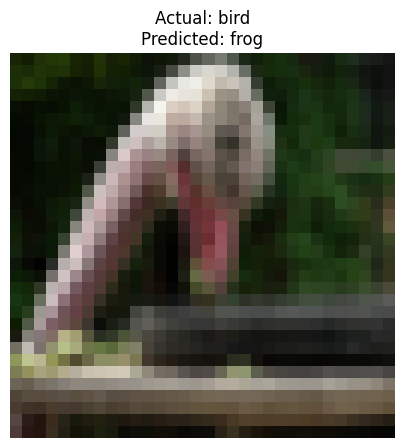


FINAL VALIDATION RESULTS
Correct Predictions: 31
Total Images: 100
Multimodal Accuracy: 31.0 %

MULTIPLE IMAGE PREDICTIONS
Image 1: Actual = bird | Predicted = frog
Image 2: Actual = airplane | Predicted = truck
Image 3: Actual = bird | Predicted = deer
Image 4: Actual = bird | Predicted = deer
Image 5: Actual = airplane | Predicted = truck
Image 6: Actual = airplane | Predicted = frog
Image 7: Actual = truck | Predicted = airplane
Image 8: Actual = airplane | Predicted = truck


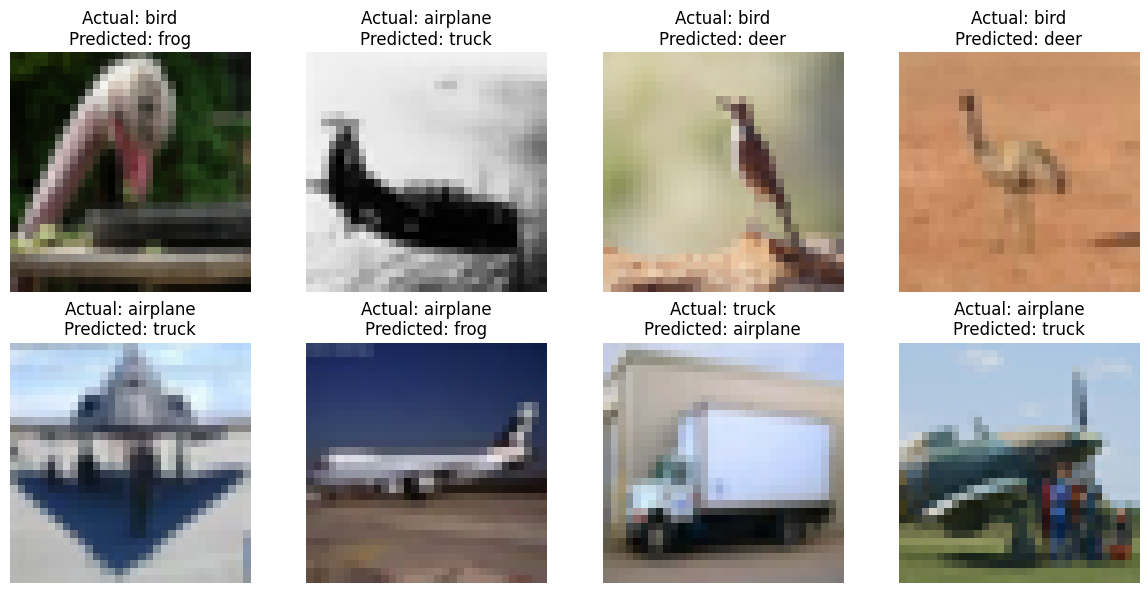


Final Model Saved: multimodal_vision_language_model.pth

PROJECT COMPLETED

PROJECT:
Multimodal AI / Vision-Language Model

DATA:
CIFAR-10 Small Subset

VISION:
Lightweight CNN Encoder

TEXT:
Lightweight Text Encoder

MULTIMODAL LEARNING:
Image-Text Contrastive Learning

INFERENCE:
Image → Embedding
Text → Embeddings
Similarity → Prediction

HARDWARE:
CPU-Friendly

STORAGE:
Very Small Model

STATUS:
END-TO-END MULTIMODAL PIPELINE COMPLETED


FINAL ARCHITECTURE

                 IMAGE
                   |
                   v
          +----------------+
          | Vision Encoder |
          |  Lightweight CNN|
          +----------------+
                   |
                   v
            Image Embedding
                   |
                   |
              Similarity
                   |
                   v
            Text Embeddings
                   ^
                   |
          +----------------+
          |  Text Encoder  |
          +----------------+
               

In [4]:
# ============================================================
# MULTIMODAL AI / VISION-LANGUAGE MODEL
# PROJECT : IMAGE + TEXT UNDERSTANDING
# PART 4 : INFERENCE + EVALUATION + VISUALIZATION
#
# CONTINUES DIRECTLY FROM PART-1, PART-2 AND PART-3
# ============================================================


# ============================================================
# SECTION 1 : IMPORT REQUIRED LIBRARIES
# ============================================================

import torch
import matplotlib.pyplot as plt

print("Part-4 Libraries Imported Successfully")


# ============================================================
# SECTION 2 : SET MODEL TO EVALUATION MODE
# ============================================================

multimodal_model.eval()

print("Multimodal Model set to evaluation mode.")


# ============================================================
# SECTION 3 : CREATE TEXT CANDIDATES
# ============================================================

# These are the possible answers/classes that the model
# will compare against the input image.


text_candidates = []


for class_name in class_names:

    text = (
        "This image contains a "
        + class_name
        + "."
    )

    text_candidates.append(text)


print()
print("=" * 60)
print("TEXT CANDIDATES")
print("=" * 60)


for i, text in enumerate(text_candidates):

    print(
        i,
        "→",
        text
    )


# ============================================================
# SECTION 4 : TOKENIZE TEXT CANDIDATES
# ============================================================

candidate_tokens = []


for text in text_candidates:

    tokens = simple_tokenize(
        text
    )

    candidate_tokens.append(tokens)


# Find maximum sequence length

max_candidate_length = max(
    len(tokens)
    for tokens in candidate_tokens
)


# ============================================================
# SECTION 5 : PAD TEXT CANDIDATES
# ============================================================

padded_candidates = []


for tokens in candidate_tokens:

    padded_tokens = (

        tokens

        +

        [
            word_to_id["<PAD>"]
        ]

        *

        (
            max_candidate_length
            -
            len(tokens)
        )

    )

    padded_candidates.append(
        padded_tokens
    )


candidate_tensor = torch.tensor(

    padded_candidates,

    dtype=torch.long

).to(device)


print()
print(
    "Candidate Tensor Shape:",
    candidate_tensor.shape
)


# ============================================================
# SECTION 6 : GENERATE TEXT EMBEDDINGS
# ============================================================

with torch.no_grad():

    candidate_embeddings = (
        multimodal_model.text_encoder(
            candidate_tensor
        )
    )


print(
    "Text Embeddings Shape:",
    candidate_embeddings.shape
)


# ============================================================
# SECTION 7 : FUNCTION FOR MULTIMODAL PREDICTION
# ============================================================

def predict_image(image):

    # Add batch dimension

    image = image.unsqueeze(0)


    # Move image to device

    image = image.to(device)


    with torch.no_grad():

        # Generate image embedding

        image_embedding = (
            multimodal_model.vision_encoder(
                image
            )
        )


        # Compare image with every text candidate

        similarity = torch.matmul(

            image_embedding,

            candidate_embeddings.T

        )


        # Get highest similarity

        predicted_index = similarity.argmax(
            dim=1
        ).item()


        # Convert similarity scores

        scores = similarity.squeeze(0)


    return (
        predicted_index,
        scores
    )


# ============================================================
# SECTION 8 : TEST ONE IMAGE
# ============================================================

test_images, test_labels = next(
    iter(validation_loader)
)


sample_image = test_images[0]

sample_label = test_labels[0].item()


predicted_index, scores = predict_image(
    sample_image
)


print()
print("=" * 60)
print("SINGLE IMAGE PREDICTION")
print("=" * 60)

print(
    "Actual Class:",
    class_names[sample_label]
)

print(
    "Predicted Class:",
    class_names[predicted_index]
)

print()
print("Similarity Scores:")


for i, score in enumerate(
    scores
):

    print(
        class_names[i],
        ":",
        round(score.item(), 4)
    )


# ============================================================
# SECTION 9 : VISUALIZE SINGLE PREDICTION
# ============================================================

# Convert normalized image back to normal range

display_image = (
    sample_image * 0.5
) + 0.5


display_image = display_image.permute(
    1,
    2,
    0
)


plt.figure(
    figsize=(5, 5)
)


plt.imshow(
    display_image
)


plt.title(
    "Actual: "
    + class_names[sample_label]
    + "\nPredicted: "
    + class_names[predicted_index]
)


plt.axis("off")

plt.show()


# ============================================================
# SECTION 10 : EVALUATE COMPLETE VALIDATION DATASET
# ============================================================

correct = 0

total = 0


with torch.no_grad():

    for images, labels in validation_loader:

        images = images.to(device)

        labels = labels.to(device)


        # ----------------------------------------------------
        # IMAGE EMBEDDINGS
        # ----------------------------------------------------

        image_embeddings = (
            multimodal_model.vision_encoder(
                images
            )
        )


        # ----------------------------------------------------
        # IMAGE-TEXT SIMILARITY
        # ----------------------------------------------------

        similarity = torch.matmul(

            image_embeddings,

            candidate_embeddings.T

        )


        # ----------------------------------------------------
        # PREDICTIONS
        # ----------------------------------------------------

        predictions = similarity.argmax(
            dim=1
        )


        # ----------------------------------------------------
        # CALCULATE CORRECT PREDICTIONS
        # ----------------------------------------------------

        correct += (
            predictions == labels
        ).sum().item()


        total += labels.size(0)


# ============================================================
# SECTION 11 : CALCULATE ACCURACY
# ============================================================

accuracy = (

    correct / total

) * 100


print()
print("=" * 60)
print("FINAL VALIDATION RESULTS")
print("=" * 60)

print(
    "Correct Predictions:",
    correct
)

print(
    "Total Images:",
    total
)

print(
    "Multimodal Accuracy:",
    round(accuracy, 2),
    "%"
)


# ============================================================
# SECTION 12 : TEST MULTIPLE IMAGES
# ============================================================

print()
print("=" * 60)
print("MULTIPLE IMAGE PREDICTIONS")
print("=" * 60)


images, labels = next(
    iter(validation_loader)
)


number_of_samples = min(
    8,
    len(images)
)


for i in range(
    number_of_samples
):

    predicted_index, scores = predict_image(
        images[i]
    )


    actual_class = class_names[
        labels[i].item()
    ]


    predicted_class = class_names[
        predicted_index
    ]


    print(
        f"Image {i + 1}: "
        f"Actual = {actual_class} | "
        f"Predicted = {predicted_class}"
    )


# ============================================================
# SECTION 13 : VISUALIZE MULTIPLE PREDICTIONS
# ============================================================

plt.figure(
    figsize=(12, 6)
)


for i in range(
    number_of_samples
):

    predicted_index, _ = predict_image(
        images[i]
    )


    display_image = (
        images[i].cpu() * 0.5
    ) + 0.5


    display_image = display_image.permute(
        1,
        2,
        0
    )


    plt.subplot(
        2,
        4,
        i + 1
    )


    plt.imshow(
        display_image
    )


    actual_class = class_names[
        labels[i].item()
    ]


    predicted_class = class_names[
        predicted_index
    ]


    plt.title(
        "Actual: "
        + actual_class
        + "\nPredicted: "
        + predicted_class
    )


    plt.axis("off")


plt.tight_layout()

plt.show()


# ============================================================
# SECTION 14 : SAVE FINAL MODEL
# ============================================================

FINAL_MODEL_PATH = (
    "multimodal_vision_language_model.pth"
)


torch.save(
    multimodal_model.state_dict(),
    FINAL_MODEL_PATH
)


print()
print(
    "Final Model Saved:",
    FINAL_MODEL_PATH
)


# ============================================================
# SECTION 15 : FINAL PROJECT SUMMARY
# ============================================================

print()
print("=" * 60)
print("PROJECT COMPLETED")
print("=" * 60)

print("""
PROJECT:
Multimodal AI / Vision-Language Model

DATA:
CIFAR-10 Small Subset

VISION:
Lightweight CNN Encoder

TEXT:
Lightweight Text Encoder

MULTIMODAL LEARNING:
Image-Text Contrastive Learning

INFERENCE:
Image → Embedding
Text → Embeddings
Similarity → Prediction

HARDWARE:
CPU-Friendly

STORAGE:
Very Small Model

STATUS:
END-TO-END MULTIMODAL PIPELINE COMPLETED
""")


# ============================================================
# SECTION 16 : FINAL ARCHITECTURE
# ============================================================

print()
print("=" * 60)
print("FINAL ARCHITECTURE")
print("=" * 60)

print("""
                 IMAGE
                   |
                   v
          +----------------+
          | Vision Encoder |
          |  Lightweight CNN|
          +----------------+
                   |
                   v
            Image Embedding
                   |
                   |
              Similarity
                   |
                   v
            Text Embeddings
                   ^
                   |
          +----------------+
          |  Text Encoder  |
          +----------------+
                   ^
                   |
              Text Prompt
                   |
                   v
       "This image contains a X"
                   |
                   v
              Prediction
""")


print()
print("============================================================")
print("PART 4 COMPLETED SUCCESSFULLY")
print("============================================================")